In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
import kagglehub

pd.set_option("display.max_columns", None)

In [4]:
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")
print(path)

/home/gregori/.cache/kagglehub/datasets/asaniczka/uk-optimal-product-price-prediction/versions/3


In [5]:
file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [6]:
df.shape

(2443651, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [8]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [9]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

### Part 1: Understanding Product Categories

**Business Question**: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. **Frequency Tables**:
    - Generate a frequency table for the product `category`.
    - Which are the top 5 most listed product categories?

2. **Visualizations**:
    - Display the distribution of products across different categories using a bar chart. *If you face problems understanding the chart, do it for a subset of top categories.*
    - For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [16]:
category_frequency = df["category"].value_counts()
category_frequency.head(10)

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Manicure & Pedicure Products               18940
Skin Care                                  18769
Make-up                                    18756
Hair Care                                  18735
Fragrances                                 18564
Name: count, dtype: int64

In [17]:
category_percentage = df["category"].value_counts(normalize=True)*100
category_percentage.head(10)

category
Sports & Outdoors                         34.221949
Beauty                                     0.790293
Handmade Clothing, Shoes & Accessories     0.786896
Bath & Body                                0.781290
Birthday Gifts                             0.776625
Manicure & Pedicure Products               0.775070
Skin Care                                  0.768072
Make-up                                    0.767540
Hair Care                                  0.766681
Fragrances                                 0.759683
Name: proportion, dtype: float64

In [18]:
category_table = pd.DataFrame({
    "frequency": category_frequency,
    "percentage": category_percentage
})
category_table.head(10)

,frequency,percentage
category,,
Sports & Outdoors,836265,34.221949
Beauty,19312,0.790293
"Handmade Clothing, Shoes & Accessories",19229,0.786896
Bath & Body,19092,0.781290
Birthday Gifts,18978,0.776625
Manicure & Pedicure Products,18940,0.775070
Skin Care,18769,0.768072
Make-up,18756,0.767540
Hair Care,18735,0.766681


In [19]:
top5_categories = df["category"].value_counts().head(5)
top5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

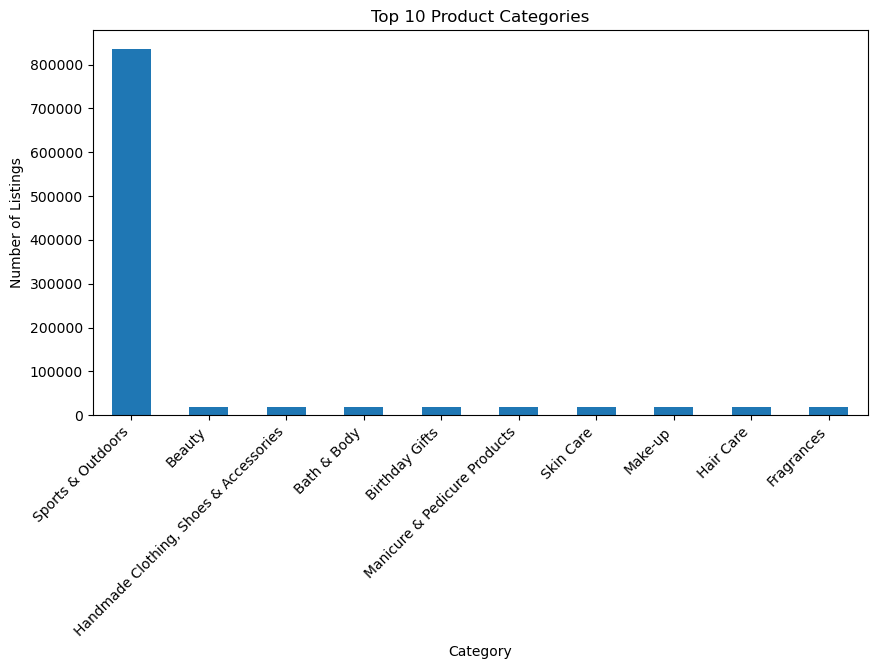

In [20]:
top10_categories = df["category"].value_counts().head(10)
top10_categories.plot(kind="bar",figsize=(10,5))
plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45, ha="right")
plt.show()

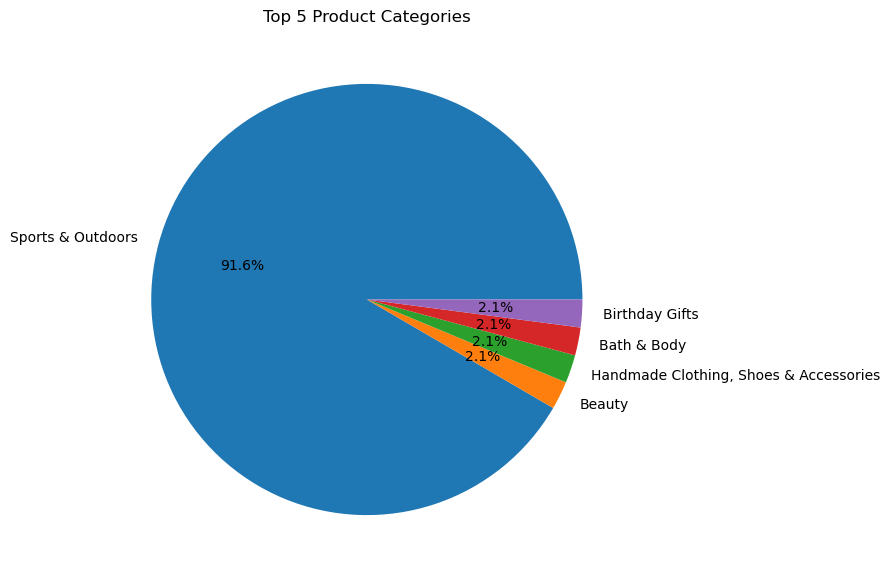

In [21]:
top5_categories.plot(kind="pie", autopct="%1.1f%%", figsize=(7,7))
plt.title("Top 5 Product Categories")
plt.ylabel("")
plt.show()

Conclusion:
- The most listed category is Sport and Outdoors
- It clearly dominates the marketplace
- amazon UK listings are not distributed evenly across categories

### Part 2: Delving into Product Pricing

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `price` of products.
    - What's the average price point of products listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, range, and interquartile range for product `price`.
    - How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:
    - Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. *If its hard to read these diagrams, think why this is, and explain how it could be solved.*.
    - Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.

In [28]:
price=df["price"]
print("Mean:", price.mean())
print("Median:", price.median())
print("Mode:",price.mode())

Mean: 89.24380943923663
Median: 19.09
Mode: 0    9.99
Name: price, dtype: float64


In [29]:
print("Variance:",price.var())
print("Standard Deviation:", price.std())
print("Minimum:", price.min())
print("Maximun:", price.max())
print("Range:", price.max()-price.min())

Variance: 119445.4853225653
Standard Deviation: 345.6088617535223
Minimum: 0.0
Maximun: 100000.0
Range: 100000.0


In [30]:
q1_price = price.quantile(0.25)
q3_price = price.quantile(0.75)
iqr_price = q3_price - q1_price
print("Q1:", q1_price)
print("Q3:", q3_price)
print("IQR:", iqr_price)

Q1: 9.99
Q3: 45.99
IQR: 36.0


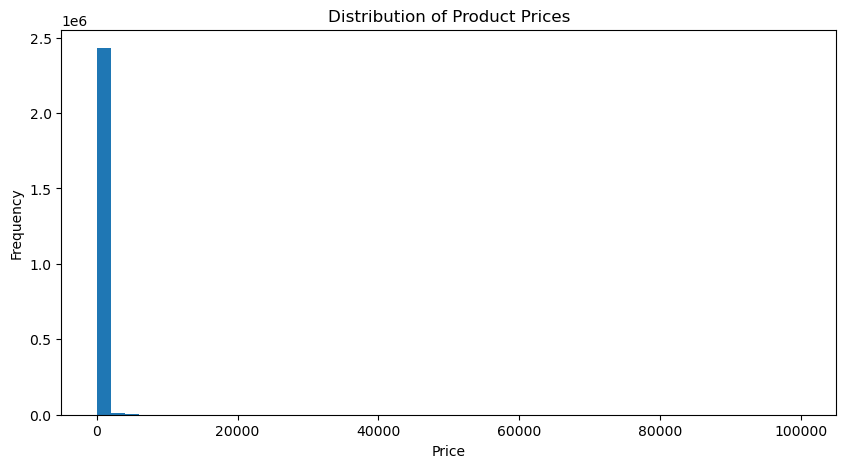

In [31]:
plt.figure(figsize=(10,5))
plt.hist(price, bins=50)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

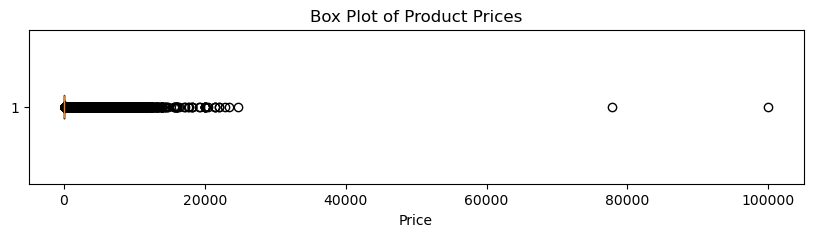

In [32]:
plt.figure(figsize=(10,2))
plt.boxplot(price, vert=False)
plt.title("Box Plot of Product Prices")
plt.xlabel("Price")
plt.show()

In [33]:
lower_limit_price=q1_price - 1.5 * iqr_price
upper_limit_price=q3_price + 1.5 * iqr_price
price_outliers=price[(price<lower_limit_price)| (price > upper_limit_price)]
print("Lower limit:", lower_limit_price)
print("Upper limit:", upper_limit_price)
print("Number of outliers:", len(price_outliers))

Lower limit: -44.01
Upper limit: 99.99000000000001
Number of outliers: 327688


Conclusion:
- The average price is much higher than the median price
- The distribution is right-skewed because there are some expensive products pushing the mean up
- The most common price is much lower than the average price
- The variance, standard deviation and box plot also show that prices are very spread out and that there  are many ouliers



### Part 3: Unpacking Product Ratings

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:
    - Calculate the mean, median, and mode for the `rating` of products.
    - How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion**:
    - Determine the variance, standard deviation, and interquartile range for product `rating`.
    - Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution**:
    - Calculate the skewness and kurtosis for the `rating` column. 
    - Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations**:
    - Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [44]:
rating = df["stars"]
print("Mean:", rating.mean())
print("Median:", rating.median())
print("Mode:")
print(rating.mode())

Mean: 2.152836472966065
Median: 0.0
Mode:
0    0.0
Name: stars, dtype: float64


In [45]:
print("Variance:", rating.var())
print("Standard Deviation:", rating.std())

Variance: 4.81743402976196
Standard Deviation: 2.1948653785054697


In [46]:
q1_rating = rating.quantile(0.25)
q3_rating = rating.quantile(0.75)
iqr_rating = q3_rating - q1_rating
print("Q1:", q1_rating)
print("Q3:", q3_rating)
print("IQR:", iqr_rating)

Q1: 0.0
Q3: 4.4
IQR: 4.4


In [47]:
print("Skewness:", rating.skew())
print("Kurtosis:", rating.kurt())

Skewness: 0.08120735761080985
Kurtosis: -1.9260061280432985


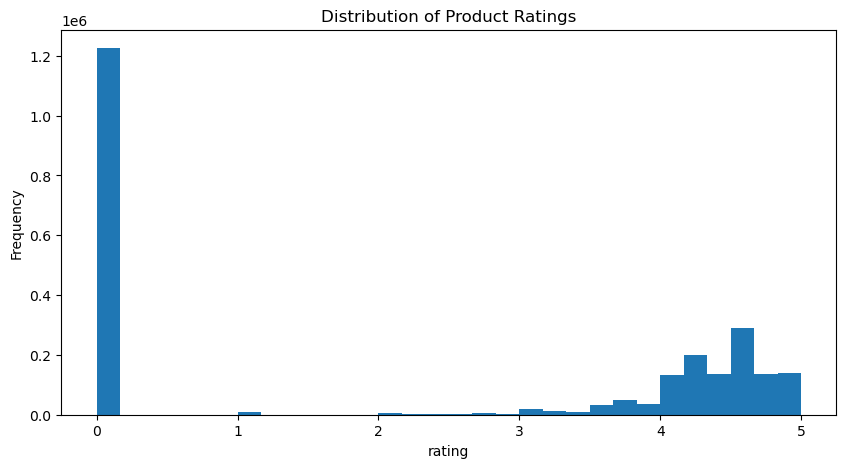

In [48]:
plt.figure(figsize=(10,5))
plt.hist(rating, bins=30)
plt.title("Distribution of Product Ratings")
plt.xlabel("rating")
plt.ylabel("Frequency")
plt.show()

Conclusion:
-The most common rating is 0, and the median is also 0
- Many products have no ratings yet or the rating is missing and stored as 0
- Because of this, the avetage rating is lower than what we might expect for rated products only
- The ratings are not normally distributed in a clean way

Global conclusions:
- Sports and Outdoors is the most popular category by far.
- The prices are very spread out and the expensive products are increasing the average
- Many products have rating of 0. This makes the distribution unusual amd explains why the median and mode are 0